In [18]:
# =============================================================================
# DKTC 위협 대화 분류 — klue/roberta-base 하이퍼파라미터 실험
#
# 원본: RoBERTa_HP_Tuning.ipynb (Reuters 46-class)
# 변경: DKTC 5-class (협박/갈취/직장내괴롭힘/기타괴롭힘/일반대화)
#
# 실험 변수 (one-factor-at-a-time):
# | 파라미터         | 탐색 범위          |
# |-----------------|-------------------|
# | learning_rate   | 1e-5, 2e-5, 5e-5  |
# | num_epochs      | 3, 5              |
# | weight_decay    | 0.0, 0.01, 0.1    |
# | lr_scheduler    | linear, cosine    |
# | warmup_ratio    | 0.0, 0.1          |
# | label_smoothing | 0.0, 0.1          |
#
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================

In [19]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())

import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)


import os, time, gc, warnings, json
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch

# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)

os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"

torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass

USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"

if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)

    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory / (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)

sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']
transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 14.73 GB


In [20]:
# ============================================================================
# 01. 데이터 로드 + 토크나이징 (1회 실행)
# ============================================================================
MODEL_NAME = "klue/roberta-base"     # 한국어 RoBERTa (111M params)
MAX_LENGTH = 512                     # 97% 커버리지 (전처리 품질 리포트 기준)
NUM_LABELS = 5                       # 협박(0), 갈취(1), 직장내괴롭힘(2), 기타괴롭힘(3), 일반대화(4)

LABEL_NAMES = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]

# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_LABELS}")
print(f"\n학습 클래스 분포:")
print(train_df["label_name"].value_counts().to_string())
print(f"\n검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())

# --- 토크나이저 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# --- Hugging Face Dataset 변환 ---
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
})

def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized_datasets = raw_datasets.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing"
)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)

# --- Class Weight 계산 (WeightedTrainer용) ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_df["label"].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
if USE_CUDA:
    class_weights_tensor = class_weights_tensor.to("cuda")

print(f"\nClass weights: {dict(zip(LABEL_NAMES, class_weights.round(3)))}")
print("토크나이징 완료 — 이후 실험에서 재사용")

Train: 3942, Val: 969, Classes: 5

학습 클래스 분포:
label_name
기타 괴롭힘 대화      808
일반 대화          800
협박 대화          778
갈취 대화          778
직장 내 괴롭힘 대화    778

검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178


Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 3942/3942 [00:00<00:00, 7122.63 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2814.52 examples/s]


Class weights: {'협박': np.float64(1.013), '갈취': np.float64(1.013), '직장내괴롭힘': np.float64(1.013), '기타괴롭힘': np.float64(0.976), '일반대화': np.float64(0.986)}
토크나이징 완료 — 이후 실험에서 재사용


In [21]:
# ============================================================================
# 02. 평가 지표 + WeightedTrainer + 실험 함수 정의
# ============================================================================
import evaluate as ev

acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }


# --- WeightedTrainer: 클래스 불균형 대응 ---
# 주의: compute_loss를 오버라이드하므로 TrainingArguments의
#       label_smoothing_factor가 무시됨. label_smoothing 실험 시
#       use_weighted_loss=False로 일반 Trainer를 사용할 것
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=class_weights_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss


# --- 단일 실험 실행 함수 ---
# [변경] val_logits 추가 반환 (top-2 확률/마진 분석용)
def run_experiment(
    exp_name,
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,                    # max_length=512 + klue/roberta-base → 16이 안전
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    use_weighted_loss=True,           # WeightedTrainer 사용 여부
):
    print("\n" + "=" * 70)
    print(f" [{exp_name}]")
    print(f"   lr={learning_rate}, epochs={num_epochs}, batch={batch_size}, "
          f"wd={weight_decay}, warmup={warmup_ratio}, "
          f"scheduler={lr_scheduler_type}, label_smooth={label_smoothing_factor}, "
          f"weighted_loss={use_weighted_loss}")
    print("=" * 70)

    # --- 모델 새로 초기화 ---
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )

    # --- TrainingArguments ---
    supports_bf16 = USE_CUDA and torch.cuda.is_bf16_supported()

    args = TrainingArguments(
        output_dir=f"./results_dktc_{exp_name}",
        num_train_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=lr_scheduler_type,
        label_smoothing_factor=label_smoothing_factor,

        per_device_train_batch_size=batch_size if USE_CUDA else 8,
        per_device_eval_batch_size=32 if USE_CUDA else 8,

        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        logging_steps=50,
        report_to="none",
        disable_tqdm=False,

        dataloader_num_workers=max(1, min(8, CPU_THREADS)),
        dataloader_pin_memory=USE_CUDA,
        dataloader_persistent_workers=True,

        fp16=USE_CUDA and not supports_bf16,
        bf16=supports_bf16,
        tf32=USE_CUDA,

        optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
        seed=42,
        save_total_limit=1,
        remove_unused_columns=True,
    )

    # --- Trainer 선택 ---
    TrainerClass = WeightedTrainer if use_weighted_loss else Trainer

    trainer = TrainerClass(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # NotebookProgressCallback 상태 꼬임 방지
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)

    # --- 학습 + 시간 측정 ---
    start = time.time()
    train_result = trainer.train()
    train_time = time.time() - start
    train_loss = train_result.metrics["train_loss"]

    # --- Epoch별 val 지표 추출 ---
    epoch_logs = []
    for log in trainer.state.log_history:
        if "eval_accuracy" in log:
            epoch_logs.append({
                "epoch": log.get("epoch"),
                "eval_loss": log.get("eval_loss"),
                "eval_accuracy": log.get("eval_accuracy"),
                "eval_f1_macro": log.get("eval_f1_macro"),
            })

    # --- Validation (best model) ---
    val_metrics = trainer.evaluate(tokenized_datasets["validation"])

    # --- Validation 상세 예측 (classification_report용) ---
    val_result = trainer.predict(tokenized_datasets["validation"])
    val_logits = val_result.predictions                       # ← [변경] logits 원본 보존
    val_preds = np.argmax(val_logits, axis=-1)
    val_labels = val_result.label_ids

    val_acc = acc_metric.compute(predictions=val_preds, references=val_labels)["accuracy"]
    val_f1m = f1_metric.compute(predictions=val_preds, references=val_labels, average="macro")["f1"]
    val_f1w = f1_metric.compute(predictions=val_preds, references=val_labels, average="weighted")["f1"]

    # --- 결과 dict ---
    result = {
        "exp_name": exp_name,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "warmup_ratio": warmup_ratio,
        "lr_scheduler": lr_scheduler_type,
        "label_smoothing": label_smoothing_factor,
        "use_weighted_loss": use_weighted_loss,
        "train_loss": round(train_loss, 4),
        "val_accuracy": round(val_acc, 4),
        "val_f1_macro": round(val_f1m, 4),
        "val_f1_weighted": round(val_f1w, 4),
        "train_time_sec": round(train_time, 1),
    }

    print(f"\n [{exp_name}] 완료 ({train_time:.0f}초)")
    print(f"   Val — Acc: {result['val_accuracy']:.4f} | F1(macro): {result['val_f1_macro']:.4f} | F1(weighted): {result['val_f1_weighted']:.4f}")

    # --- 메모리 해제 ---
    del model, trainer
    gc.collect()
    if USE_CUDA:
        torch.cuda.empty_cache()

    # [변경] val_logits 추가 반환
    return result, epoch_logs, val_preds, val_labels, val_logits


print("실험 함수 정의 완료")

실험 함수 정의 완료


In [22]:
# ============================================================================
# 03. 실험 목록 정의 + 실행
# ============================================================================
# Baseline: lr=2e-5, ep=3, wd=0.01, linear, warmup=0.1, weighted_loss=True

BASE = dict(
    learning_rate=2e-5,
    num_epochs=3,
    batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    label_smoothing_factor=0.0,
    use_weighted_loss=True,
)

EXPERIMENTS = [
    # 1. Baseline
    {"exp_name": "baseline",    **BASE},

    # 2~3. Learning Rate
    {"exp_name": "lr_1e-5",     **{**BASE, "learning_rate": 1e-5}},
    {"exp_name": "lr_5e-5",     **{**BASE, "learning_rate": 5e-5}},

    # 4. Epoch
    {"exp_name": "epoch_5",     **{**BASE, "num_epochs": 5}},

    # 5~6. Weight Decay
    {"exp_name": "wd_0",        **{**BASE, "weight_decay": 0.0}},
    {"exp_name": "wd_0.1",      **{**BASE, "weight_decay": 0.1}},

    # 7. Cosine Scheduler
    {"exp_name": "cosine",      **{**BASE, "lr_scheduler_type": "cosine"}},

    # 8. Warmup 없음
    {"exp_name": "no_warmup",   **{**BASE, "warmup_ratio": 0.0}},

    # 9. Label Smoothing (WeightedTrainer가 compute_loss를 오버라이드하므로
    #    label_smoothing은 일반 Trainer에서만 동작)
    {"exp_name": "smooth_0.1",  **{**BASE, "label_smoothing_factor": 0.1, "use_weighted_loss": False}},

    # 10. WeightedLoss 비교 (일반 Trainer)
    {"exp_name": "no_weight",   **{**BASE, "use_weighted_loss": False}},
]

print(f"실험 {len(EXPERIMENTS)}개 예정")
for i, e in enumerate(EXPERIMENTS, 1):
    print(f"  {i:2d}. {e['exp_name']}")

실험 10개 예정
   1. baseline
   2. lr_1e-5
   3. lr_5e-5
   4. epoch_5
   5. wd_0
   6. wd_0.1
   7. cosine
   8. no_warmup
   9. smooth_0.1
  10. no_weight


In [23]:
# ============================================================================
# 실험 루프 실행
# ============================================================================
all_results = []
all_epoch_logs = {}
all_val_preds = {}       # 실험별 예측 저장
all_val_logits = {}      # [변경] 실험별 logits 저장 (top-2 분석용)
all_val_labels = None     # 레이블은 동일하므로 1번만

for exp in EXPERIMENTS:
    result, epoch_logs, val_preds, val_labels, val_logits = run_experiment(**exp)  # ← [변경]
    all_results.append(result)
    all_epoch_logs[exp["exp_name"]] = epoch_logs
    all_val_preds[exp["exp_name"]] = val_preds
    all_val_logits[exp["exp_name"]] = val_logits    # ← [변경]
    if all_val_labels is None:
        all_val_labels = val_labels

print(f"\n{'=' * 70}")
print(f"전체 실험 완료: {len(all_results)}개")
print(f"총 소요 시간: {sum(r['train_time_sec'] for r in all_results):.0f}초 "
      f"({sum(r['train_time_sec'] for r in all_results)/60:.1f}분)")
print(f"{'=' * 70}")



 [baseline]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1872.43it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [baseline] 완료 (113초)
   Val — Acc: 0.9143 | F1(macro): 0.9147 | F1(weighted): 0.9150

 [lr_1e-5]
   lr=1e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1799.28it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [lr_1e-5] 완료 (107초)
   Val — Acc: 0.9143 | F1(macro): 0.9138 | F1(weighted): 0.9145

 [lr_5e-5]
   lr=5e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=True


...


 [no_warmup] 완료 (107초)
   Val — Acc: 0.9267 | F1(macro): 0.9260 | F1(weighted): 0.9267

 [smooth_0.1]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.1, weighted_loss=False


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2000.36it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [smooth_0.1] 완료 (110초)
   Val — Acc: 0.9257 | F1(macro): 0.9260 | F1(weighted): 0.9262

 [no_weight]
   lr=2e-05, epochs=3, batch=16, wd=0.01, warmup=0.1, scheduler=linear, label_smooth=0.0, weighted_loss=False


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1976.76it/s]
RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be


 [no_weight] 완료 (109초)
   Val — Acc: 0.9247 | F1(macro): 0.9245 | F1(weighted): 0.9250

전체 실험 완료: 10개
총 소요 시간: 1160초 (19.3분)


In [ ]:
# ============================================================================
# 04. 전체 결과 비교
# ============================================================================
df = pd.DataFrame(all_results)

# Baseline 대비 성능 변화량
baseline_row = df[df["exp_name"] == "baseline"].iloc[0]
df["delta_val_f1_macro"] = df["val_f1_macro"] - baseline_row["val_f1_macro"]

# 정렬: val_f1_macro 내림차순
df_sorted = df.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)

print("전체 실험 결과 (Val F1 Macro 내림차순)")
print("=" * 100)

display_cols = [
    "exp_name", "learning_rate", "num_epochs", "weight_decay",
    "lr_scheduler", "warmup_ratio", "label_smoothing", "use_weighted_loss",
    "val_accuracy", "val_f1_macro", "val_f1_weighted",
    "delta_val_f1_macro", "train_time_sec"
]
display(df_sorted[display_cols].style
    .format({
        "learning_rate": "{:.0e}",
        "val_accuracy": "{:.4f}",
        "val_f1_macro": "{:.4f}",
        "val_f1_weighted": "{:.4f}",
        "delta_val_f1_macro": "{:+.4f}",
    })
    .background_gradient(subset=["val_f1_macro"], cmap="RdYlGn", vmin=0.7, vmax=1.0)
    .background_gradient(subset=["delta_val_f1_macro"], cmap="RdYlGn", vmin=-0.05, vmax=0.05)
)

전체 실험 결과 (Val F1 Macro 내림차순)


,exp_name,learning_rate,num_epochs,weight_decay,lr_scheduler,warmup_ratio,label_smoothing,use_weighted_loss,val_accuracy,val_f1_macro,val_f1_weighted,delta_val_f1_macro,train_time_sec
0,no_warmup,2e-05,3,0.010000,linear,0.000000,0.000000,True,0.9267,0.9260,0.9267,+0.0113,107.300000
1,smooth_0.1,2e-05,3,0.010000,linear,0.100000,0.100000,False,0.9257,0.9260,0.9262,+0.0113,110.200000
2,wd_0,2e-05,3,0.000000,linear,0.100000,0.000000,True,0.9257,0.9256,0.9260,+0.0109,107.100000
3,no_weight,2e-05,3,0.010000,linear,0.100000,0.000000,False,0.9247,0.9245,0.9250,+0.0098,108.700000
4,wd_0.1,2e-05,3,0.100000,linear,0.100000,0.000000,True,0.9236,0.9233,0.9240,+0.0086,106.900000
5,epoch_5,2e-05,5,0.010000,linear,0.100000,0.000000,True,0.9226,0.9221,0.9226,+0.0074,178.800000
6,cosine,2e-05,3,0.010000,cosine,0.100000,0.000000,True,0.9216,0.9212,0.9218,+0.0065,109.900000
7,lr_5e-5,5e-05,3,0.010000,linear,0.100000,0.000000,True,0.9164,0.9160,0.9164,+0.0013,110.500000
8,baseline,2e-05,3,0.010000,linear,0.100000,0.000000,True,0.9143,0.9147,0.9150,+0.0000,113.400000
9,lr_1e-5,1e-05,3,0.010000,linear,0.100000,0.000000,True,0.9143,0.9138,0.9145,-0.0009,107.100000


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

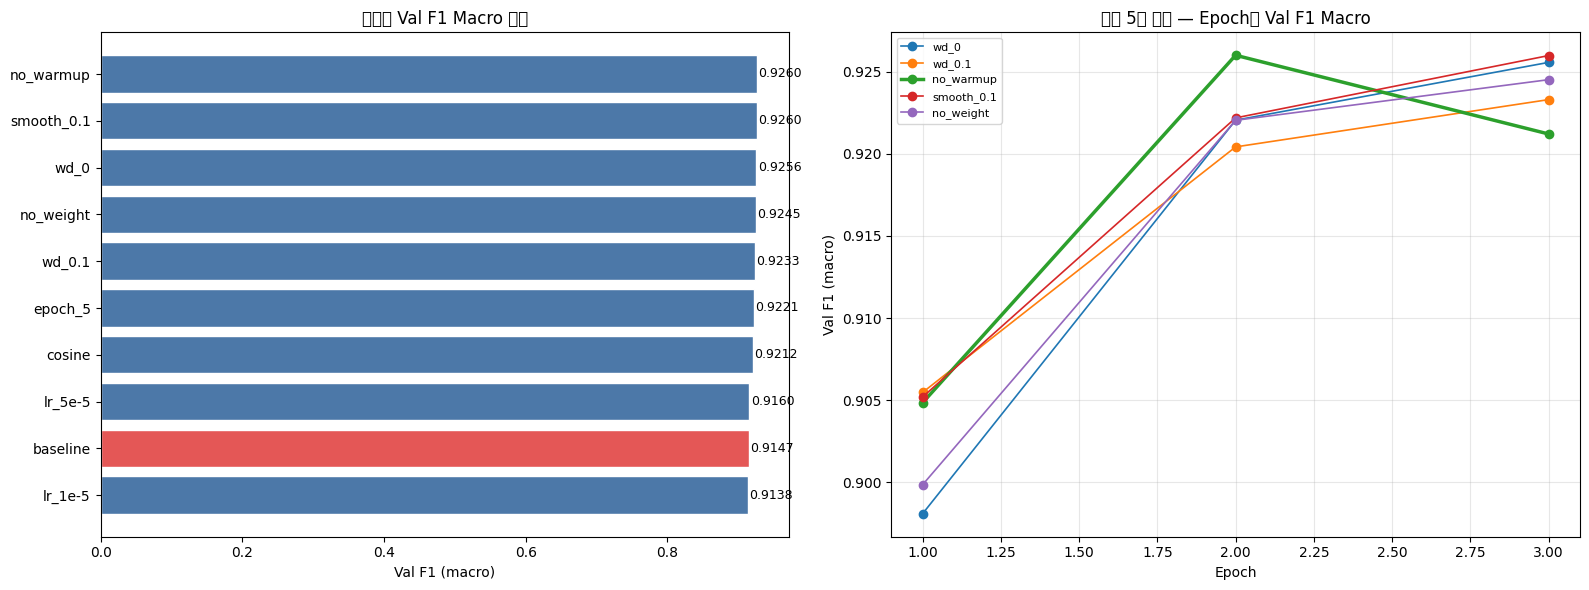

  → 저장: dktc_hp_experiment_chart.png


In [25]:
# ============================================================================
# 05. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 한글 폰트 ---
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# --- (a) 실험별 Val F1 Macro 비교 바 차트 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors = ["#E45756" if r["exp_name"] == "baseline" else "#4C78A8" for r in all_results]
sorted_results = sorted(all_results, key=lambda x: x["val_f1_macro"], reverse=True)
names = [r["exp_name"] for r in sorted_results]
f1s = [r["val_f1_macro"] for r in sorted_results]
bar_colors = ["#E45756" if n == "baseline" else "#4C78A8" for n in names]

ax.barh(names, f1s, color=bar_colors, edgecolor="white")
ax.set_xlabel("Val F1 (macro)")
ax.set_title("실험별 Val F1 Macro 비교")
ax.invert_yaxis()
for i, v in enumerate(f1s):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# --- (b) Epoch별 학습 곡선 (상위 5개) ---
ax = axes[1]
top5 = [r["exp_name"] for r in sorted_results[:5]]
for exp_name, logs in all_epoch_logs.items():
    if not logs or exp_name not in top5:
        continue
    epochs = [l["epoch"] for l in logs]
    f1_vals = [l["eval_f1_macro"] for l in logs]
    lw = 2.5 if exp_name == sorted_results[0]["exp_name"] else 1.2
    ax.plot(epochs, f1_vals, marker="o", label=exp_name, linewidth=lw)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val F1 (macro)")
ax.set_title("상위 5개 실험 — Epoch별 Val F1 Macro")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dktc_hp_experiment_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_hp_experiment_chart.png")


In [26]:
# ============================================================================
# 06. Best 모델 상세 분석 (classification_report)
# ============================================================================
best_name = df_sorted.iloc[0]["exp_name"]
best_preds = all_val_preds[best_name]
best_logits = all_val_logits[best_name]   # ← [변경] logits 가져오기
best_f1 = df_sorted.iloc[0]["val_f1_macro"]

print(f"Best 모델: {best_name} (Val F1 Macro: {best_f1:.4f})")
print("=" * 70)
print(classification_report(
    all_val_labels,
    best_preds,
    target_names=LABEL_NAMES,
    digits=4
))

# 오분류 패턴 분석
from collections import Counter
wrong_mask = best_preds != all_val_labels
if wrong_mask.sum() > 0:
    print(f"\n오분류 건수: {wrong_mask.sum()} / {len(all_val_labels)} ({wrong_mask.mean()*100:.1f}%)")
    print("\n오분류 패턴 (실제→예측):")
    wrong_pairs = list(zip(all_val_labels[wrong_mask], best_preds[wrong_mask]))
    for (true_cls, pred_cls), cnt in Counter(wrong_pairs).most_common(10):
        print(f"  {LABEL_NAMES[true_cls]:10s} → {LABEL_NAMES[pred_cls]:10s}: {cnt}건")


Best 모델: no_warmup (Val F1 Macro: 0.9260)
              precision    recall  f1-score   support

          협박     0.9217    0.8596    0.8895       178
          갈취     0.8939    0.9077    0.9008       195
      직장내괴롭힘     0.9487    0.9536    0.9512       194
       기타괴롭힘     0.8774    0.9208    0.8986       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9267       969
   macro avg     0.9273    0.9253    0.9260       969
weighted avg     0.9274    0.9267    0.9267       969


오분류 건수: 71 / 969 (7.3%)

오분류 패턴 (실제→예측):
  협박         → 기타괴롭힘     : 12건
  협박         → 갈취        : 10건
  기타괴롭힘      → 갈취        : 9건
  갈취         → 협박        : 8건
  직장내괴롭힘     → 기타괴롭힘     : 7건
  갈취         → 기타괴롭힘     : 6건
  기타괴롭힘      → 협박        : 5건
  갈취         → 직장내괴롭힘    : 4건
  협박         → 직장내괴롭힘    : 3건
  직장내괴롭힘     → 갈취        : 2건


In [27]:
# ============================================================================
# 07. 결과 저장
# ============================================================================
# CSV 저장
df_final = pd.DataFrame(all_results)
df_final.to_csv("dktc_hp_experiment_results.csv", index=False)
#
# Epoch 히스토리 JSON 저장
with open("dktc_hp_epoch_logs.json", "w") as f:
    json.dump(all_epoch_logs, f, indent=2)

print("dktc_hp_experiment_results.csv 저장 완료")
print("dktc_hp_epoch_logs.json 저장 완료")
print(f"\n총 실험 수: {len(all_results)}")
print(f"총 소요 시간: {df_final['train_time_sec'].sum():.0f}초 ({df_final['train_time_sec'].sum()/60:.1f}분)")
print(f"\nBest: {best_name} → Val F1 Macro: {best_f1:.4f}")

dktc_hp_experiment_results.csv 저장 완료
dktc_hp_epoch_logs.json 저장 완료

총 실험 수: 10
총 소요 시간: 1160초 (19.3분)

Best: no_warmup → Val F1 Macro: 0.9260


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.



 오분류 원문 + top-2 확률/마진 분석
Best 모델: no_warmup (Val F1 Macro: 0.9260)
검증 샘플 수: 969
텍스트 컬럼: text

[오분류 전체] 71건 / 969건 (7.3%)

오분류 패턴 (실제→예측):
error_pair
협박 → 기타괴롭힘        12
협박 → 갈취           10
기타괴롭힘 → 갈취         9
갈취 → 협박            8
직장내괴롭힘 → 기타괴롭힘     7
갈취 → 기타괴롭힘         6
기타괴롭힘 → 협박         5
갈취 → 직장내괴롭힘        4
협박 → 직장내괴롭힘        3
일반대화 → 직장내괴롭힘      2
직장내괴롭힘 → 갈취        2
일반대화 → 기타괴롭힘       1
기타괴롭힘 → 직장내괴롭힘     1
기타괴롭힘 → 일반대화       1

저장 완료: dktc_all_misclassified_with_top2.csv

저장 완료: dktc_misclassification_pair_summary.csv
  [협박 → 기타괴롭힘]  12건 (mean margin=0.905) → misclassified_pairs_with_top2/협박_to_기타괴롭힘_csv
  [협박 → 갈취]  10건 (mean margin=0.879) → misclassified_pairs_with_top2/협박_to_갈취_csv
  [기타괴롭힘 → 갈취]   9건 (mean margin=0.814) → misclassified_pairs_with_top2/기타괴롭힘_to_갈취_csv
  [갈취 → 협박]   8건 (mean margin=0.635) → misclassified_pairs_with_top2/갈취_to_협박_csv
  [직장내괴롭힘 → 기타괴롭힘]   7건 (mean margin=0.574) → misclassified_pairs_with_top2/직장내괴롭힘_to_기타괴롭힘_csv
  [갈취 → 기타괴롭힘]   6건 (mean m

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

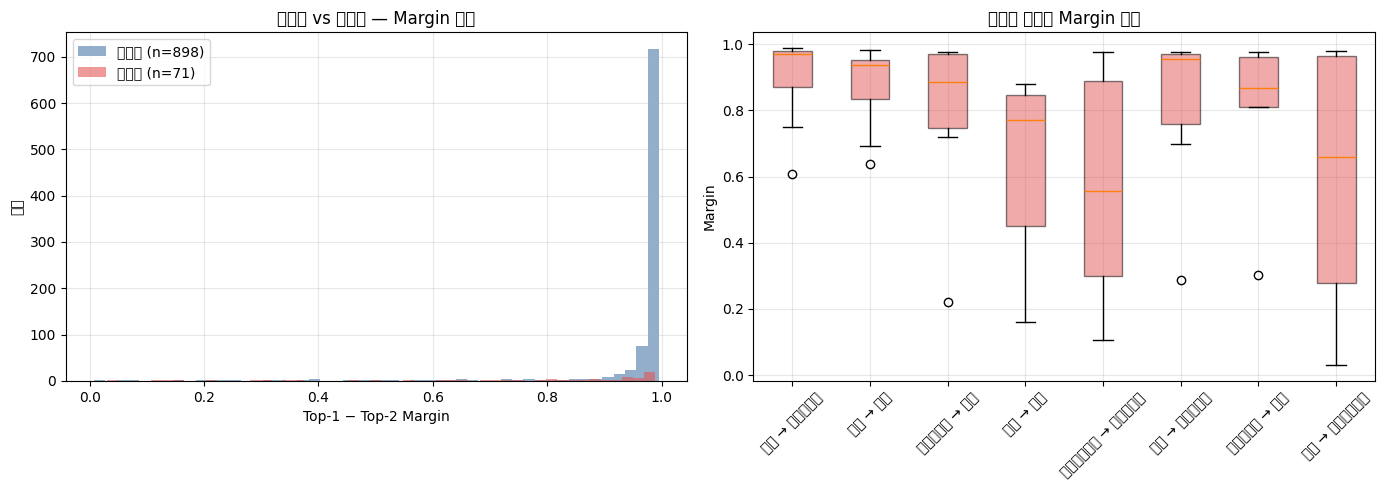

  → 저장: dktc_misclassification_margin_analysis.png

완료


In [28]:
# ============================================================================
# 08. 오분류 원문 + top-2 확률/마진 분석 (HP 튜닝 단일 모델 기준)
#
# 사용 변수:
#   best_preds, best_logits, all_val_labels, val_df, LABEL_NAMES, df_sorted
# ============================================================================

import os, re
import numpy as np
import pandas as pd
from collections import Counter

print("\n" + "=" * 70)
print(" 오분류 원문 + top-2 확률/마진 분석")
print("=" * 70)

# ---------------------------------------------------------------------------
# 0) 유틸
# ---------------------------------------------------------------------------
def softmax_np(x):
    """Numerically stable softmax"""
    x = np.asarray(x, dtype=np.float64)
    x_max = np.max(x, axis=1, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=1, keepdims=True)

def top2_from_logits(logits, label_names):
    """logits → top-1/top-2 레이블, 확률, 마진"""
    probs = softmax_np(logits)
    order = np.argsort(-probs, axis=1)[:, :2]
    top1_id  = order[:, 0]
    top2_id  = order[:, 1]
    top1_prob = probs[np.arange(len(probs)), top1_id]
    top2_prob = probs[np.arange(len(probs)), top2_id]
    margin    = top1_prob - top2_prob
    return {
        "top1_id":    top1_id,
        "top1_label": np.array([label_names[int(i)] for i in top1_id], dtype=object),
        "top1_prob":  top1_prob,
        "top2_id":    top2_id,
        "top2_label": np.array([label_names[int(i)] for i in top2_id], dtype=object),
        "top2_prob":  top2_prob,
        "margin":     margin,
        "probs":      probs,
    }

def safe_filename(s: str) -> str:
    s = re.sub(r"[^\w가-힣\- ]+", "_", s)
    return s.replace(" ", "_")

# ---------------------------------------------------------------------------
# 1) 필수 변수 확인
# ---------------------------------------------------------------------------
assert "best_preds"     in dir(), "best_preds가 없습니다. 셀 06을 먼저 실행하세요."
assert "best_logits"    in dir(), "best_logits가 없습니다. 셀 06을 먼저 실행하세요."
assert "all_val_labels" in dir(), "all_val_labels가 없습니다."
assert "val_df"         in dir(), "val_df가 없습니다."
assert "LABEL_NAMES"    in dir(), "LABEL_NAMES가 없습니다."
assert "df_sorted"      in dir(), "df_sorted가 없습니다."

best_name = df_sorted.iloc[0]["exp_name"]
best_f1   = df_sorted.iloc[0]["val_f1_macro"]

print(f"Best 모델: {best_name} (Val F1 Macro: {best_f1:.4f})")
print(f"검증 샘플 수: {len(val_df)}")

# ---------------------------------------------------------------------------
# 2) 텍스트 컬럼 자동 탐색
# ---------------------------------------------------------------------------
text_col = None
for c in ["text", "sentence", "document", "utterance", "content"]:
    if c in val_df.columns:
        text_col = c
        break
if text_col is None:
    raise RuntimeError(f"텍스트 컬럼을 찾지 못했습니다. 실제 컬럼: {list(val_df.columns)}")

print(f"텍스트 컬럼: {text_col}")

# ---------------------------------------------------------------------------
# 3) top-2 확률/마진 계산
# ---------------------------------------------------------------------------
y_true = np.asarray(all_val_labels).astype(int)
y_pred = np.asarray(best_preds).astype(int)

t2 = top2_from_logits(best_logits, LABEL_NAMES)

# ---------------------------------------------------------------------------
# 4) 결과 테이블 생성
# ---------------------------------------------------------------------------
df_analysis = val_df.copy().reset_index(drop=False).rename(columns={"index": "orig_index"})

df_analysis["true_label_id"]  = y_true
df_analysis["pred_label_id"]  = y_pred
df_analysis["true_label"]     = df_analysis["true_label_id"].map(lambda x: LABEL_NAMES[int(x)])
df_analysis["pred_label"]     = df_analysis["pred_label_id"].map(lambda x: LABEL_NAMES[int(x)])
df_analysis["is_wrong"]       = y_true != y_pred
df_analysis["error_pair"]     = df_analysis["true_label"] + " → " + df_analysis["pred_label"]

# top-2 정보 추가
df_analysis["top1_label"] = t2["top1_label"]
df_analysis["top1_prob"]  = t2["top1_prob"]
df_analysis["top2_label"] = t2["top2_label"]
df_analysis["top2_prob"]  = t2["top2_prob"]
df_analysis["margin"]     = t2["margin"]

# 클래스별 확률 열
for i, name in enumerate(LABEL_NAMES):
    df_analysis[f"prob_{name}"] = t2["probs"][:, i]

# ---------------------------------------------------------------------------
# 5) 오분류 전체 추출
# ---------------------------------------------------------------------------
errors_df = df_analysis[df_analysis["is_wrong"]].copy()

print(f"\n[오분류 전체] {len(errors_df)}건 / {len(df_analysis)}건 "
      f"({len(errors_df)/len(df_analysis)*100:.1f}%)")
print("\n오분류 패턴 (실제→예측):")
print(errors_df["error_pair"].value_counts().to_string())

errors_df.to_csv(
    "dktc_all_misclassified_with_top2.csv",
    index=False,
    encoding="utf-8-sig"
)
print("\n저장 완료: dktc_all_misclassified_with_top2.csv")

# ---------------------------------------------------------------------------
# 6) 오분류 패턴별 요약 + 개별 CSV 저장
# ---------------------------------------------------------------------------
out_dir = "misclassified_pairs_with_top2"
os.makedirs(out_dir, exist_ok=True)

pair_summary = (
    errors_df.groupby(["true_label", "pred_label"])
    .agg(
        count=("is_wrong", "size"),
        mean_margin=("margin", "mean"),
        min_margin=("margin", "min"),
        max_margin=("margin", "max"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
pair_summary["error_pair"] = pair_summary["true_label"] + " → " + pair_summary["pred_label"]
pair_summary.to_csv("dktc_misclassification_pair_summary.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: dktc_misclassification_pair_summary.csv")

for _, row in pair_summary.iterrows():
    true_name = row["true_label"]
    pred_name = row["pred_label"]
    cnt       = int(row["count"])

    pair_df = errors_df[
        (errors_df["true_label"] == true_name) &
        (errors_df["pred_label"] == pred_name)
    ].copy().sort_values("margin", ascending=True).reset_index(drop=True)

    save_name = safe_filename(f"{true_name}_to_{pred_name}.csv")
    save_path = os.path.join(out_dir, save_name)
    pair_df.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"  [{true_name} → {pred_name}] {cnt:3d}건 (mean margin={row['mean_margin']:.3f}) → {save_path}")

# ---------------------------------------------------------------------------
# 7) 애매한 오분류 top-30 / 확신 오분류 top-30
# ---------------------------------------------------------------------------
ambiguous_top = errors_df.sort_values("margin", ascending=True).head(30).copy()
confident_wrong_top = errors_df.sort_values("margin", ascending=False).head(30).copy()

ambiguous_top.to_csv(
    "dktc_misclassified_most_ambiguous_top30.csv",
    index=False, encoding="utf-8-sig"
)
confident_wrong_top.to_csv(
    "dktc_misclassified_most_confident_top30.csv",
    index=False, encoding="utf-8-sig"
)
print("\n저장 완료: dktc_misclassified_most_ambiguous_top30.csv")
print("저장 완료: dktc_misclassified_most_confident_top30.csv")

# ---------------------------------------------------------------------------
# 8) 주요 오분류 패턴별 원문 샘플 출력
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print(" 주요 오분류 패턴별 원문 샘플 (상위 5패턴, 각 3건)")
print("=" * 70)

for _, row in pair_summary.head(5).iterrows():
    true_name = row["true_label"]
    pred_name = row["pred_label"]
    cnt       = int(row["count"])

    pair_df = errors_df[
        (errors_df["true_label"] == true_name) &
        (errors_df["pred_label"] == pred_name)
    ].sort_values("margin", ascending=True)   # 가장 애매한 건부터

    print(f"\n--- [{true_name} → {pred_name}] ({cnt}건, mean margin={row['mean_margin']:.3f}) ---")
    for i, (_, sample) in enumerate(pair_df.head(3).iterrows()):
        text_preview = str(sample[text_col])[:120].replace("\n", " ")
        print(f"  [{i+1}] margin={sample['margin']:.3f} | "
              f"top1={sample['top1_label']}({sample['top1_prob']:.2%}) "
              f"top2={sample['top2_label']}({sample['top2_prob']:.2%})")
        print(f"      \"{text_preview}...\"")

# ---------------------------------------------------------------------------
# 9) margin 분포 시각화
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 정분류 vs 오분류 margin 분포
ax = axes[0]
correct_margins = df_analysis[~df_analysis["is_wrong"]]["margin"]
wrong_margins   = errors_df["margin"]

ax.hist(correct_margins, bins=50, alpha=0.6, label=f"정분류 (n={len(correct_margins)})", color="#4C78A8")
ax.hist(wrong_margins,   bins=50, alpha=0.6, label=f"오분류 (n={len(wrong_margins)})",   color="#E45756")
ax.set_xlabel("Top-1 − Top-2 Margin")
ax.set_ylabel("빈도")
ax.set_title("정분류 vs 오분류 — Margin 분포")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) 오분류 패턴별 margin boxplot (상위 8개)
ax = axes[1]
top_pairs = pair_summary.head(8)["error_pair"].tolist()
box_data = [errors_df[errors_df["error_pair"] == p]["margin"].values for p in top_pairs]

bp = ax.boxplot(box_data, labels=top_pairs, vert=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#E45756")
    patch.set_alpha(0.5)
ax.set_ylabel("Margin")
ax.set_title("오분류 패턴별 Margin 분포")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dktc_misclassification_margin_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_misclassification_margin_analysis.png")

print("\n완료")